# Embeddings, Attention, and Transformers

## Embeddings

Last lecture, we discussed how tokenizers process strings and turn them into sequences of integer IDs. LLMs can't "handle" strings on their own, but it turns out that they can't handle integers either! 

When we tokenize our input, we have a tensor with shape $(B, L)$, where $B$ is the batch size (how many sequences we are processing in parallel) and $L$ is the sequence length (how many tokens are in each of our sequences). The embedding layer of the model maps each integer ID to a *dense vector* of dimensionality D, such that our input has shape $(B, L, D)$: $B$ sequences, each length $L$, composed of $D$-dimensional representations. 

These embeddings are learned during training, just like any other weights in the model. PyTorch has an `Embedding` layer that is easy to use for this purpose. Let's take a look at how it works!

In [1]:
import torch
from torch import nn
from torch.nn import functional as F


embedding_layer = nn.Embedding(num_embeddings=7, embedding_dim=3, padding_idx=0)

In [2]:
print("Embedding weights:\n", embedding_layer.weight)

Embedding weights:
 Parameter containing:
tensor([[ 0.0000,  0.0000,  0.0000],
        [-0.0270,  1.2107,  1.2715],
        [ 1.0338, -0.4638,  0.8187],
        [-0.4787,  0.4873, -0.3080],
        [ 0.1147,  0.2642,  0.7554],
        [-0.3598,  0.8334,  0.8015],
        [ 0.7806, -0.8529, -0.7077]], requires_grad=True)


Let's talk about the constructor. 
- `num_embeddings` specifies the total number of embeddings we can learn (rows in the embedding weight matrix). This should be the size of our tokenizer's vocabulary: each token has its own unique embedding. 
- `embedding_dim` is the dimensionality of each embedding (columns in the embedding matrix). 
- `padding_idx` specifies which row will be used for padding. It will not be updated during training and is used to represent empty space. As you can see above,it is set to all 0s. We'll see how it works in a second. 

Let's see how these different parts fit together.

In [3]:
token2id = {
    "PAD": 0,
    "hello": 1,
    "world": 2,
    "darkness": 3,
    "my": 4,
    "old": 5,
    "friend":6
}

sentences = [
    "hello world", "hello darkness my old friend"
]

split_sentences = [s.split() for s in sentences] # Split into words
max_len = max(len(s) for s in split_sentences)
split_sentences = [s + ["PAD"]*(max_len - len(s)) for s in split_sentences] # Pad to max length
print("Padded pretokenized sentences:\n", split_sentences)

tokenized = [[token2id[w] for w in s] for s in split_sentences]
print("Tokenized sentence:\n", tokenized)


Padded pretokenized sentences:
 [['hello', 'world', 'PAD', 'PAD', 'PAD'], ['hello', 'darkness', 'my', 'old', 'friend']]
Tokenized sentence:
 [[1, 2, 0, 0, 0], [1, 3, 4, 5, 6]]


In [4]:
tokenized_tensor = torch.tensor(tokenized)

with torch.no_grad():
    print("Input shape:\n", tokenized_tensor.shape)
    embeds = embedding_layer(tokenized_tensor)
    print("Embeddings:\n", embeds)
    print("Embeddings shape:\n", embeds.shape)

Input shape:
 torch.Size([2, 5])
Embeddings:
 tensor([[[-0.0270,  1.2107,  1.2715],
         [ 1.0338, -0.4638,  0.8187],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000]],

        [[-0.0270,  1.2107,  1.2715],
         [-0.4787,  0.4873, -0.3080],
         [ 0.1147,  0.2642,  0.7554],
         [-0.3598,  0.8334,  0.8015],
         [ 0.7806, -0.8529, -0.7077]]])
Embeddings shape:
 torch.Size([2, 5, 3])


## Attention
Attention is what the course has been building towards so far. Without attention, we arguably would not have anything like LLMs as we know them today. It is hard to overstate how important the attention mechanism has been to the contemporary AI landscape. 

Before we talk about how attention works, let's briefly revisit MLPs. Let's look at the cell below:

In [5]:
W = torch.randn(3, 2)
b = torch.randn(2)

print("Input:\n", embeds[0])
print("Output:\n", F.linear(embeds[0], W.T, b))

Input:
 tensor([[-0.0270,  1.2107,  1.2715],
        [ 1.0338, -0.4638,  0.8187],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000]])
Output:
 tensor([[-4.3078,  5.1704],
        [-1.9175,  1.7144],
        [-1.1102,  1.1487],
        [-1.1102,  1.1487],
        [-1.1102,  1.1487]])


This (random) single MLP layer takes 3D input and outputs transformed 2D output. We can give it the entire sequence of embeddings and get our entire sequence back out, transformed. However, take note:

In [6]:
torch.allclose(
    F.linear(embeds[0][0], W.T, b), # MLP of first row in first sequence
    F.linear(embeds[0], W.T, b)[0], # MLP of first sequence, then extract first row
)

True

The MLP only acts on the $D$ dimension of our input: every embedding is transformed independently of every other embedding in the sequence. That's great, but on its own, it doesn't actually help us model language very much. Think about what you're reading right now: you have to take into account the prior words you've read to make sense of the next word. A classic case of why this matters so much is *polysemy*, or words that can have multiple meanings: 

- *I went fishing on the river **bank**.*
- *He dropped a check off at the **bank**.*

How do we know which **bank** we're talking about in each sentence? We use *context*: you don't go fishing at Wells Fargo, and it's a bad idea to drop your paycheck into a river. The big challenge is how to build a model that learns which parts of a sequence are important to one another.  

In technical terms: it's easy to mix *within* a token representation (we can use an MLP), but it's hard to mix *across* tokens in a sequence. 

### What is attention?

#### Generally

Attention is an elegant and effective solution to this problem. Attention is kind of what it sounds like: it helps us know how much each representation in our sequence should "attend" to every other one. There are different kinds of attention, but what we'll be talking about is *Scaled Dot Product Attention*. You will frequently see it written like this:

$$Attention(Q, K, V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$$

$Q$: Query matrix

$K$: Key matrix

$V$: Value matrix

$d_k$: Number of columns in $K$

*(These names (query, key, value) come from retrieval, and they are relevant to how attention works, but it can be confusing to think in these terms at first. For now, we'll just refer to them by $Q$, $K$, and $V$.)*

Let's break down what's going on here, working from the inside out. 

The matrix $QK^T$'s entries are the dot products between all rows in $Q$ and all rows in $K$. Dot product tells us how similar a row is to another row (think about why that is). $QK^T$ has shape $(N_Q, N_K)$, where $N_A$ is the number of rows in $A$. We then scale these values by the square root of $d_k$, which is the number of columns in $K$. We do this because our dot product values (and their variance) are likely to grow with the number of columns in our $Q$ and $K$ matrices, since we're taking a sum of more elements. Scaling helps us keep these values under control. 

We then take the softmax of each row of our scaled dot product matrix. Each entry $ij$ in this matrix represents how much row $i$ in $Q$ has in common with row $j$ in $K$. By taking the softmax, we transform each row into a probability distribution: all elements are between 0 and 1 and sum to 1. This matrix is often called the *attention matrix*. When we multiply $V$ by this matrix, we are performing a *weighted mixing across the rows of $V$*. 

#### In an LLM
Let's make this more concrete. Fortunately for us, in a language model, we usually are performing Scaled Dot Product *Self* Attention, meaning that Q, K, and V are all linear projections of the same input matrix. Formally, if an input $X$ has shape $(L, D)$, 

$Q = XW_Q$

$K = XW_K$

$V = XW_V$

where $W \in \R^{d \times d}$,

This means that $\frac{QK^T}{\sqrt{d_k}}$ has shape $(L, L)$. In plain English, why does this matter? What does this accomplish? 

*We have simplified attention here. In reality, attention is computed with multiple attention heads. This complicates things only a little bit, and if you can grasp the above, you can understand multi-head attention fine. For simplicity, we're treating attention as though it's computed with only one head.*

## Transformers

The transformer architecture was introduced in Vaswani et al. 2017, "Attention is All you Need". You can think of a transformer as blocks of attention followed by an MLP. There is more to it, and I think this is best introduced through code. Let's go through it now. 

We're going to introduce the transformer through code here and talk a little more about it next week. We'll talk through each part of the code in detail to make sure you understand the important stuff (we also might hand wave away some details).

We'll be training a character model (i.e. each token is a letter) to write Shakespeare. Don't get your hopes up: our model will only have about 100k parameters! 

In [7]:
class Tokenizer:
    def __init__(self):
        vocab = "abcdefghijklmnopqrstuvwxyz.!?:;,'-\" \n"
        self.c2id = {c: i for i, c in enumerate(vocab)}
        self.c2id["UNK"] = len(vocab)
        self.c2id["<s>"] = len(vocab) + 1
        self.c2id["</s>"] = len(vocab) + 2

        self.id2c = {v: k for k, v in self.c2id.items()}

    def tokenize(self, text):
        text = text.lower()
        output = [self.c2id["<s>"]]
        for c in text:
            if c in self.c2id:
                output.append(self.c2id[c])
            else:
                output.append(self.c2id["UNK"])
        return output + [self.c2id["</s>"]]
    
    def untokenize(self, ids):
        return [self.id2c[t] for t in ids]

In [8]:
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_Q = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_K = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_V = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.d_k = hidden_dim # / num_heads, which is 1, so hidden dim

    def forward(self, x):
        seq_len = x.size()[1]
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        # We use this to assure that the model can't "see" future tokens.
        mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)
        causal_mask = torch.zeros(seq_len, seq_len).masked_fill(mask, float('-inf'))

        scores = Q @ K.transpose(-2, -1) / (self.d_k ** 0.5)
        scores += causal_mask
        attn = F.softmax(scores, dim=-1)

        return attn @ V, attn        

In [9]:
class TransformerLayer(nn.Module):
    def __init__(self, hidden_dim, expansion_factor):
        super().__init__()
        self.attention = SelfAttention(hidden_dim)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim*expansion_factor),
            nn.ReLU(),
            nn.Linear(hidden_dim*expansion_factor, hidden_dim)
        )
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
    
    def forward(self, x):
        h, attn = self.attention(x)
        h = self.norm1(h + x) # "Add and norm" 
        z = self.mlp(h)
        return self.norm2(z + h), attn # "Add and norm"


class Transformer(nn.Module):
    def __init__(self, d_model=8, n_vocab=10, expansion_factor=4, num_layers=3, max_length=50):
        super().__init__()
        self.positional_encoding = nn.Embedding(max_length, d_model)
        self.embedding = nn.Embedding(n_vocab, d_model)

        self.layers = nn.ModuleList(
            [TransformerLayer(d_model, expansion_factor) for _ in range(num_layers)]
        )       

    def forward(self, input_ids):
        x = self.embedding(input_ids) + self.positional_encoding(torch.arange(input_ids.shape[1]))
        attns = []
        for layer in self.layers:
            x, attn = layer(x) 
            attns.append(attn)
        return x @ self.embedding.weight.T, attns

In [10]:
from datasets import load_dataset

shakespeare = load_dataset("winglian/tiny-shakespeare")

train/data-00000-of-00001.arrow:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

test/data-00000-of-00001.arrow:   0%|          | 0.00/120k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/472 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/49 [00:00<?, ? examples/s]

In [11]:
truncate_len = 100
train = [s[:truncate_len] for s in shakespeare["train"]["text"] if len(s) > truncate_len] # All training the same length. 

tokenizer = Tokenizer()

X = torch.tensor([tokenizer.tokenize(s)[:-1] for s in train])
Y = torch.tensor([tokenizer.tokenize(s)[1:] for s in train])

print("".join(tokenizer.untokenize(X[0].tolist())))

<s>first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you


In [12]:
shakespeare["test"]["text"][0]

"TRANIO:\nIs this your speeding? nay, then, good night our part!\n\nPETRUCHIO:\nBe patient, gentlemen; I choose her for myself:\nIf she and I be pleased, what's that to you?\n'Tis bargain'd 'twixt us twain, being alone,\nThat she shall still be curst in company.\nI tell you, 'tis incredible to believe\nHow much she loves me: O, the kindest Kate!\nShe hung about my neck; and kiss on kiss\nShe vied so fast, protesting oath on oath,\nThat in a twink she won me to her love.\nO, you are novices! 'tis a world to see,\nHow tame, when men and women are alone,\nA meacock wretch can make the curstest shrew.\nGive me thy hand, Kate: I will unto Venice,\nTo buy apparel 'gainst the wedding-day.\nProvide the feast, father, and bid the guests;\nI will be sure my Katharina shall be fine.\n\nBAPTISTA:\nI know not what to say: but give me your hands;\nGod send you joy, Petruchio! 'tis a match.\n\nGREMIO:\nAmen, say we: we will be witnesses.\n\nPETRUCHIO:\nFather, and wife, and gentlemen, adieu;\nI will 

In [13]:
def generate(model, tokenizer, prompt, max_tokens=50):
    model.eval()
    ids = tokenizer.tokenize(prompt)[:-1]
    eos = tokenizer.c2id["</s>"]

    with torch.no_grad():
        for _ in range(max_tokens):
            logits, _ = model(torch.tensor([ids]))
            next_id = logits[0, -1].argmax().item()
            if next_id == eos:
                break
            ids.append(next_id)

    return "".join(tokenizer.untokenize(ids))

Mess around with the model hyperparameters here. What happens when you train with a larger/smaller batch size?  Learning rate (`lr`)? `d_model`? How good can you get the model output to be? 

In [ ]:
model = Transformer(d_model=128, n_vocab=len(tokenizer.c2id), num_layers=12, max_length=truncate_len+2)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)

batch_size = 32

vocab_size = len(tokenizer.c2id)

losses = []
for epoch in range(500):
    perm = torch.randperm(len(X))
    X = X[perm]
    Y = Y[perm]
    for i in range(0, len(train), batch_size): 
        batch_x = X[i:i+batch_size]
        batch_y = Y[i:i+batch_size]
        logits, _ = model(batch_x)
        loss = F.cross_entropy(logits.view(-1, vocab_size), batch_y.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} loss: {loss.item()}")
    print(f"Generation with prompt 'nay, then, good night our part!':\n", generate(model, tokenizer, "nay, then, good night our part!"))
    losses.append(loss.item())


Epoch 0 loss: 8.14450454711914
Generation with prompt 'nay, then, good night our part!':
 <s>nay, then, good night our part!oooooooooooooooooooooooooooooooooooooooooooooooooo
Epoch 1 loss: 4.110552787780762
Generation with prompt 'nay, then, good night our part!':
 <s>nay, then, good night our part!rrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr
Epoch 2 loss: 3.6051409244537354
Generation with prompt 'nay, then, good night our part!':
 <s>nay, then, good night our part!hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh
Epoch 3 loss: 3.2821478843688965
Generation with prompt 'nay, then, good night our part!':
 <s>nay, then, good night our part!                                                  
Epoch 4 loss: 3.175342321395874
Generation with prompt 'nay, then, good night our part!':
 <s>nay, then, good night our part!                                                  
Epoch 5 loss: 3.113776922225952
Generation with prompt 'nay, then, good night our part!':
 <s>nay, then, good night our

In [15]:
# How big is this model? 

sum(p.numel() for p in model.parameters())

556672

<Axes: xlabel='step', ylabel='loss'>

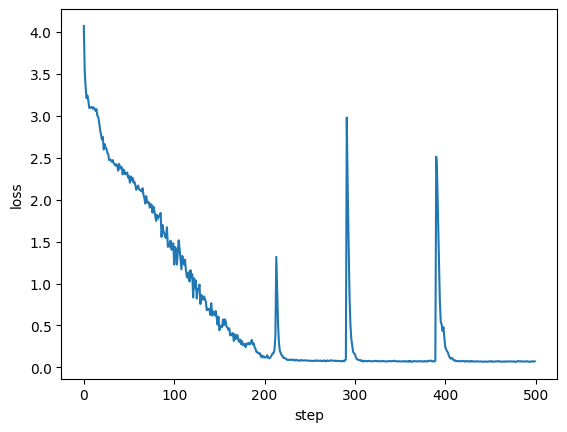

In [16]:
import pandas as pd
import seaborn as sns 

# Draw the loss curve
sns.lineplot(
    data=pd.DataFrame.from_dict({"loss": losses, "step": list(range(len(losses)))}),
    x="step",
    y="loss"
)

In [19]:
# Generation
generate(model, tokenizer, "to be or not to be: that is the ")

'<s>to be or not to be: that is the i vofear, mpppoouce\nart theandu gor, marengrenchar'

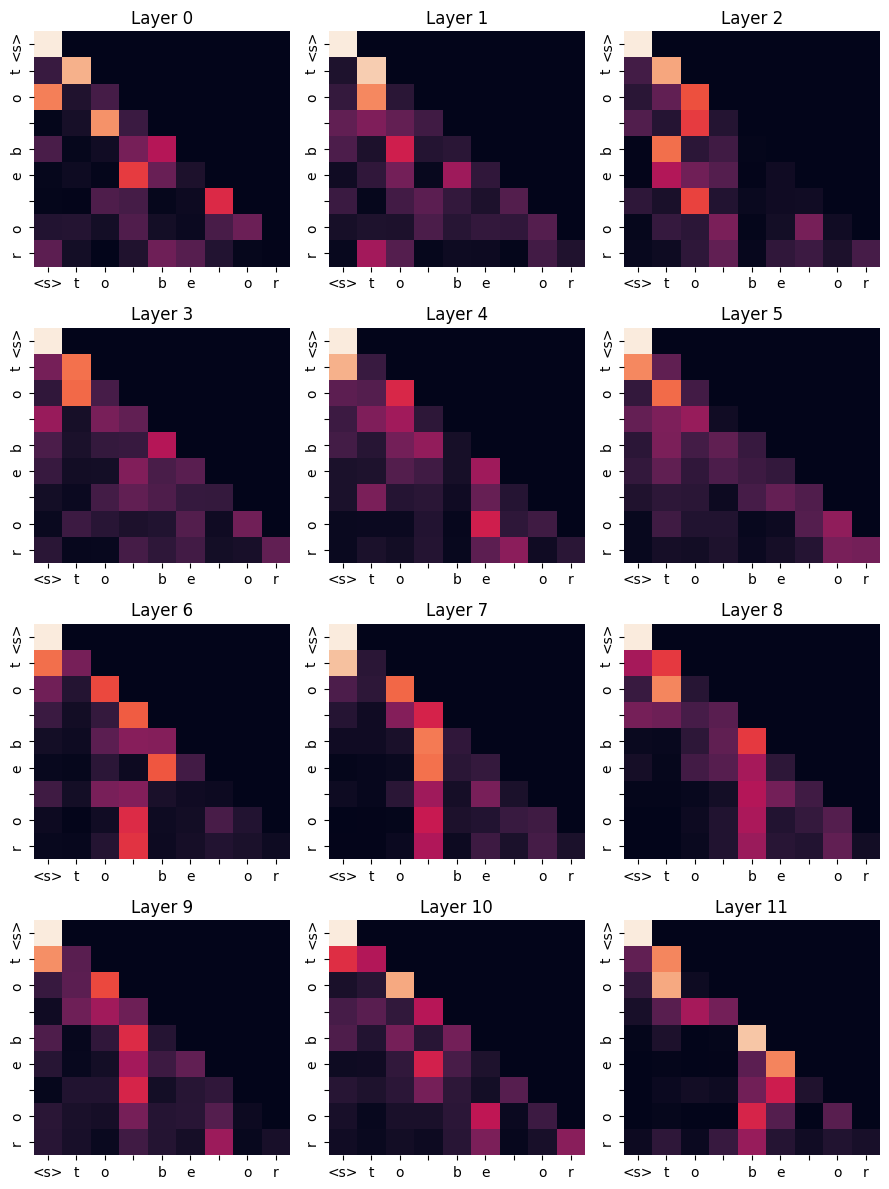

In [20]:
x = (tokenizer.tokenize("to be or"))[:-1]
with torch.no_grad():
    _, attns = model(torch.tensor(x).unsqueeze(0))


import matplotlib.pyplot as plt


n_rows = 4 
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(9, 12))
labels = tokenizer.untokenize(x)

for i, mat in enumerate(attns):
    row = i // n_cols
    col = i % n_cols
    sns.heatmap(
        data=attns[i][0], cbar=False, ax=axs[row][col],
        xticklabels=labels, yticklabels=labels
    )
    axs[row][col].set(title=f"Layer {i}")

plt.tight_layout()
plt.show()